# Energy Drink Price Range Prediction

## Data Cleaning Phase

Objective:
Prepare the survey dataset for machine learning modeling by:

- Removing duplicate records
- Detecting and handling outliers
- Treating missing values
- Correcting inconsistent categorical values

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv("../data/raw/survey_results.csv")

print("Shape:", df.shape)

df.head()

Shape: (30010, 17)


,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
4,R00005,23,M,Metro,Student,NaN,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30010 entries, 0 to 30009
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   respondent_id                   30010 non-null  str  
 1   age                             30010 non-null  int64
 2   gender                          30010 non-null  str  
 3   zone                            30010 non-null  str  
 4   occupation                      30010 non-null  str  
 5   income_levels                   21946 non-null  str  
 6   consume_frequency(weekly)       30002 non-null  str  
 7   current_brand                   30010 non-null  str  
 8   preferable_consumption_size     30010 non-null  str  
 9   awareness_of_other_brands       30010 non-null  str  
 10  reasons_for_choosing_brands     30010 non-null  str  
 11  flavor_preference               30010 non-null  str  
 12  purchase_channel                30000 non-null  str  
 13  packaging_pr

In [4]:
df.describe(include="all")

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
count,30010,30010.000000,30010,30010,30010,21946,30002,30010,30010,30010,30010,30010,30000,30010,30010,30010,30010
unique,30000,NaN,2,6,4,5,3,4,3,3,4,2,2,3,3,3,4
top,R02309,NaN,M,Metro,Working Professional,16L - 25L,3-4 times,Established,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,High (Very health-conscious),"Active (eg. Sports, gym)",200-250
freq,2,NaN,16146,11915,15812,5905,11795,15450,13228,12969,14144,15112,16576,14456,11922,11259,9719
mean,NaN,33.047684,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,13.439250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,23.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.isnull().sum()

respondent_id                        0
age                                  0
gender                               0
zone                                 0
occupation                           0
income_levels                     8064
consume_frequency(weekly)            8
current_brand                        0
preferable_consumption_size          0
awareness_of_other_brands            0
reasons_for_choosing_brands          0
flavor_preference                    0
purchase_channel                    10
packaging_preference                 0
health_concerns                      0
typical_consumption_situations       0
price_range                          0
dtype: int64

## Step 1: Duplicate Detection and Removal

Duplicate records can bias model training by over-representing certain respondents and patterns.

We first identify duplicates and then remove them if necessary.

In [6]:
duplicate_rows = df.duplicated()

print("Number of duplicate rows:", duplicate_rows.sum())

Number of duplicate rows: 10


In [7]:
df[df.duplicated()].head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
2309,R02309,27,M,Urban,Working Professional,16L - 25L,3-4 times,Newcomer,Small (250 ml),2 to 4,Brand Reputation,Traditional,Online,Simple,Medium (Moderately health-conscious),Social (eg. Parties),150-200
2666,R02665,61,M,Metro,Entrepreneur,16L - 25L,3-4 times,Established,Medium (500 ml),above 4,Brand Reputation,Exotic,Retail Store,Simple,High (Very health-conscious),"Active (eg. Sports, gym)",200-250
5151,R05149,21,M,Semi-Urban,Student,NaN,3-4 times,Established,Small (250 ml),2 to 4,Availability,Traditional,Retail Store,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
7794,R07791,25,M,Metro,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
8516,R08512,20,F,Metro,Student,NaN,5-7 times,Established,Large (1 L),0 to 1,Price,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150


In [8]:
duplicate_ids = df['respondent_id'].duplicated().sum()

print("Duplicate respondent IDs:", duplicate_ids)

Duplicate respondent IDs: 10


In [9]:
df[df['respondent_id'].duplicated(keep=False)]\
    .sort_values('respondent_id')

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
2308,R02309,27,M,Urban,Working Professional,16L - 25L,3-4 times,Newcomer,Small (250 ml),2 to 4,Brand Reputation,Traditional,Online,Simple,Medium (Moderately health-conscious),Social (eg. Parties),150-200
2309,R02309,27,M,Urban,Working Professional,16L - 25L,3-4 times,Newcomer,Small (250 ml),2 to 4,Brand Reputation,Traditional,Online,Simple,Medium (Moderately health-conscious),Social (eg. Parties),150-200
2665,R02665,61,M,Metro,Entrepreneur,16L - 25L,3-4 times,Established,Medium (500 ml),above 4,Brand Reputation,Exotic,Retail Store,Simple,High (Very health-conscious),"Active (eg. Sports, gym)",200-250
2666,R02665,61,M,Metro,Entrepreneur,16L - 25L,3-4 times,Established,Medium (500 ml),above 4,Brand Reputation,Exotic,Retail Store,Simple,High (Very health-conscious),"Active (eg. Sports, gym)",200-250
5150,R05149,21,M,Semi-Urban,Student,NaN,3-4 times,Established,Small (250 ml),2 to 4,Availability,Traditional,Retail Store,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
5151,R05149,21,M,Semi-Urban,Student,NaN,3-4 times,Established,Small (250 ml),2 to 4,Availability,Traditional,Retail Store,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
7793,R07791,25,M,Metro,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
7794,R07791,25,M,Metro,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
8516,R08512,20,F,Metro,Student,NaN,5-7 times,Established,Large (1 L),0 to 1,Price,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
8515,R08512,20,F,Metro,Student,NaN,5-7 times,Established,Large (1 L),0 to 1,Price,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150


In [10]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (30000, 17)


In [11]:
print("Remaining duplicate rows:", df.duplicated().sum())
print("Remaining duplicate IDs:",
      df['respondent_id'].duplicated().sum())

Remaining duplicate rows: 0
Remaining duplicate IDs: 0


### Observation

- 10 duplicate records were detected.
- 10 respondent IDs were duplicated.
- Duplicate entries represented repeated records and were removed.
- Dataset size reduced from 30,010 rows to 30,000 rows.

## Step 2: Outlier Detection in Age

Outliers can distort statistical analysis and negatively impact model performance.

The age column is examined using descriptive statistics and boxplots.

In [12]:
df['age'].describe()

count    30000.000000
mean        33.048167
std         13.438904
min         18.000000
25%         23.000000
50%         31.000000
75%         40.000000
max        604.000000
Name: age, dtype: float64

In [13]:
print("Minimum age:", df['age'].min())
print("Maximum age:", df['age'].max())

Minimum age: 18
Maximum age: 604


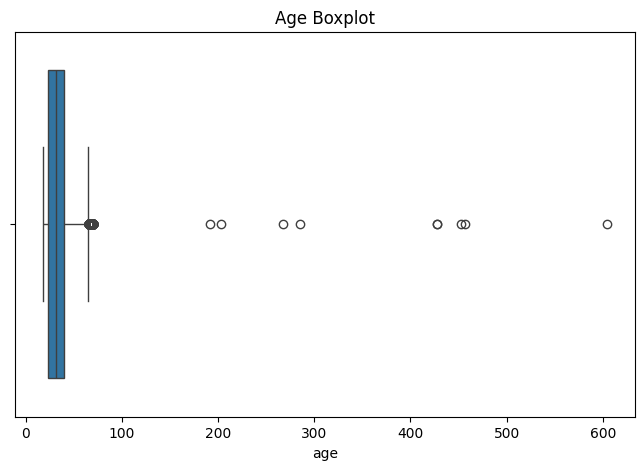

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['age'])

plt.title("Age Boxplot")
plt.show()

In [15]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 23.0
Q3: 40.0
IQR: 17.0
Lower Bound: -2.5
Upper Bound: 65.5


In [16]:
age_outliers = df[
    (df['age'] < lower_bound) |
    (df['age'] > upper_bound)
]

print("Number of age outliers:", len(age_outliers))

Number of age outliers: 493


In [17]:
age_outliers.sort_values('age')

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
29872,R29863,66,M,Urban,Retired,<10L,5-7 times,Newcomer,Large (1 L),2 to 4,Price,Traditional,Retail Store,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",150-200
29837,R29828,66,F,Metro,Retired,<10L,0-2 times,Established,Small (250 ml),0 to 1,Availability,Exotic,Retail Store,Simple,Low (Not very concerned),Casual (eg. At home),100-150
1640,R01641,66,M,Metro,Retired,<10L,0-2 times,Established,Small (250 ml),2 to 4,Price,Traditional,Retail Store,Simple,High (Very health-conscious),Casual (eg. At home),150-200
1751,R01752,66,M,Metro,Entrepreneur,> 35L,3-4 times,Established,Small (250 ml),above 4,Brand Reputation,Traditional,Online,Premium,Low (Not very concerned),Casual (eg. At home),200-250
1926,R01927,66,F,Metro,Retired,<10L,3-4 times,Newcomer,Small (250 ml),0 to 1,Price,Exotic,Retail Store,Simple,High (Very health-conscious),"Active (eg. Sports, gym)",150-200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28770,R28761,428,F,Rural,Working Professional,26L - 35L,0-2 times,Established,Small (250 ml),2 to 4,Brand Reputation,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),150-200
6262,R06260,428,M,Urban,Entrepreneur,16L - 25L,5-7 times,Established,Large (1 L),above 4,Quality,Exotic,Online,Simple,High (Very health-conscious),Social (eg. Parties),200-250
3099,R03098,453,M,Metro,Working Professional,26L - 35L,3-4 times,Established,Medium (500 ml),2 to 4,Brand Reputation,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
22549,R22542,457,M,Metro,Working Professional,16L - 25L,3-4 times,Newcomer,Small (250 ml),2 to 4,Price,Traditional,Online,Premium,High (Very health-conscious),Casual (eg. At home),200-250


### Investigating Extreme Age Values

The IQR method identifies statistical outliers, but not all outliers are invalid.

We inspect unusually high ages to distinguish legitimate respondents from erroneous entries.

In [18]:
df['age'].sort_values(ascending=False).head(20)

12403    604
22549    457
3099     453
28770    428
6262     428
24958    285
22918    267
25105    203
24960    192
8710      70
25419     70
19956     70
5376      70
27707     70
7853      70
5235      70
8739      70
5941      70
25238     70
11002     70
Name: age, dtype: int64

In [19]:
df[df['age'] > 100]['age'].value_counts().sort_index()

age
192    1
203    1
267    1
285    1
428    2
453    1
457    1
604    1
Name: count, dtype: int64

In [20]:
df[df['age'] > 100].sort_values('age')

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
24960,R24952,192,F,Urban,Student,NaN,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
25105,R25096,203,M,Metro,Working Professional,16L - 25L,0-2 times,Established,Small (250 ml),2 to 4,Brand Reputation,Exotic,Retail Store,Premium,High (Very health-conscious),"Active (eg. Sports, gym)",150-200
22918,R22911,267,F,Metro,Working Professional,16L - 25L,3-4 times,Established,Medium (500 ml),above 4,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
24958,R24950,285,M,Semi-Urban,Working Professional,> 35L,0-2 times,Newcomer,Small (250 ml),2 to 4,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",150-200
6262,R06260,428,M,Urban,Entrepreneur,16L - 25L,5-7 times,Established,Large (1 L),above 4,Quality,Exotic,Online,Simple,High (Very health-conscious),Social (eg. Parties),200-250
28770,R28761,428,F,Rural,Working Professional,26L - 35L,0-2 times,Established,Small (250 ml),2 to 4,Brand Reputation,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),150-200
3099,R03098,453,M,Metro,Working Professional,26L - 35L,3-4 times,Established,Medium (500 ml),2 to 4,Brand Reputation,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
22549,R22542,457,M,Metro,Working Professional,16L - 25L,3-4 times,Newcomer,Small (250 ml),2 to 4,Price,Traditional,Online,Premium,High (Very health-conscious),Casual (eg. At home),200-250
12403,R12398,604,M,Metro,Retired,<10L,0-2 times,Newcomer,Small (250 ml),2 to 4,Availability,Traditional,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150


In [21]:
df_clean = df.copy()

In [22]:
rows_before = len(df_clean)

df_clean = df_clean[df_clean['age'] <= 100]

rows_after = len(df_clean)

print("Rows removed:", rows_before - rows_after)
print("New shape:", df_clean.shape)

Rows removed: 9
New shape: (29991, 17)


In [23]:
print(df_clean['age'].min())
print(df_clean['age'].max())

18
70


### Observation

- The IQR method flagged 493 statistical outliers.
- Most of these represented legitimate older respondents and were retained.
- Nine records contained impossible ages (>100 years), likely caused by data-entry errors.
- These records were removed from the dataset.

## Step 3: Handling Missing Values

Missing values can negatively affect model training and evaluation.

Each feature is analyzed individually before selecting an imputation strategy.

In [24]:
df.isnull().sum()

respondent_id                        0
age                                  0
gender                               0
zone                                 0
occupation                           0
income_levels                     8061
consume_frequency(weekly)            8
current_brand                        0
preferable_consumption_size          0
awareness_of_other_brands            0
reasons_for_choosing_brands          0
flavor_preference                    0
purchase_channel                    10
packaging_preference                 0
health_concerns                      0
typical_consumption_situations       0
price_range                          0
dtype: int64

In [25]:
df['income_levels'].value_counts(dropna=False)

income_levels
NaN          8061
16L - 25L    5901
10L - 15L    5251
<10L         4662
26L - 35L    3874
> 35L        2251
Name: count, dtype: int64

In [26]:
df['consume_frequency(weekly)'].value_counts(dropna=False)

consume_frequency(weekly)
3-4 times    11790
5-7 times     9775
0-2 times     8427
NaN              8
Name: count, dtype: int64

In [27]:
df['purchase_channel'].value_counts(dropna=False)

purchase_channel
Online          16569
Retail Store    13421
NaN                10
Name: count, dtype: int64

In [28]:
missing_pct = (
    df.isnull().sum() /
    len(df) * 100
).sort_values(ascending=False)

missing_pct

income_levels                     26.870000
purchase_channel                   0.033333
consume_frequency(weekly)          0.026667
respondent_id                      0.000000
age                                0.000000
occupation                         0.000000
zone                               0.000000
current_brand                      0.000000
gender                             0.000000
preferable_consumption_size        0.000000
awareness_of_other_brands          0.000000
reasons_for_choosing_brands        0.000000
flavor_preference                  0.000000
packaging_preference               0.000000
health_concerns                    0.000000
typical_consumption_situations     0.000000
price_range                        0.000000
dtype: float64

### Missing Value Treatment Strategy

- income_levels:
  Missing values are replaced with "Not Reported" to preserve information and avoid introducing bias.

- consume_frequency(weekly):
  Missing values are replaced using the mode category.

- purchase_channel:
  Missing values are replaced using the mode category.

In [29]:
# income_levels -> Not Reported

df['income_levels'] = df['income_levels'].fillna('Not Reported')

# consume_frequency(weekly) -> Mode

freq_mode = df['consume_frequency(weekly)'].mode()[0]

df['consume_frequency(weekly)'] = (
    df['consume_frequency(weekly)']
    .fillna(freq_mode)
)

# purchase_channel -> Mode

channel_mode = df['purchase_channel'].mode()[0]

df['purchase_channel'] = (
    df['purchase_channel']
    .fillna(channel_mode)
)

In [30]:
df.isnull().sum()

respondent_id                     0
age                               0
gender                            0
zone                              0
occupation                        0
income_levels                     0
consume_frequency(weekly)         0
current_brand                     0
preferable_consumption_size       0
awareness_of_other_brands         0
reasons_for_choosing_brands       0
flavor_preference                 0
purchase_channel                  0
packaging_preference              0
health_concerns                   0
typical_consumption_situations    0
price_range                       0
dtype: int64

In [31]:
df['income_levels'].value_counts()

income_levels
Not Reported    8061
16L - 25L       5901
10L - 15L       5251
<10L            4662
26L - 35L       3874
> 35L           2251
Name: count, dtype: int64

### Observation

- income_levels contained 8,061 missing values (26.87%).
- Missing income values were replaced with the category "Not Reported".
- consume_frequency(weekly) contained 8 missing values and was imputed using the mode category (3-4 times).
- purchase_channel contained 10 missing values and was imputed using the mode category (Online).
- The dataset now contains no missing values.

## Step 4: Categorical Consistency Check

Categorical variables are inspected for spelling mistakes,
inconsistent capitalization, extra spaces, and duplicate labels.

In [32]:
print("ZONE")
print(sorted(df['zone'].unique()))

print("\nCURRENT BRAND")
print(sorted(df['current_brand'].unique()))

ZONE
['Metor', 'Metro', 'Rural', 'Semi-Urban', 'Urban', 'urbna']

CURRENT BRAND
['Establishd', 'Established', 'Newcomer', 'newcomer']


In [33]:
print(df['zone'].value_counts())

print("\n")

print(df['current_brand'].value_counts())

zone
Metro         11911
Urban         10688
Semi-Urban     5275
Rural          2117
urbna             5
Metor             4
Name: count, dtype: int64


current_brand
Established    15447
Newcomer       14503
newcomer          30
Establishd        20
Name: count, dtype: int64


In [34]:
df['zone'] = df['zone'].replace({
    'Metor': 'Metro',
    'urbna': 'Urban'
})

In [35]:
df['current_brand'] = df['current_brand'].replace({
    'newcomer': 'Newcomer',
    'Establishd': 'Established'
})

In [36]:
print("ZONE")
print(sorted(df['zone'].unique()))

print("\nZONE COUNTS")
print(df['zone'].value_counts())

print("\nCURRENT BRAND")
print(sorted(df['current_brand'].unique()))

print("\nCURRENT BRAND COUNTS")
print(df['current_brand'].value_counts())

ZONE
['Metro', 'Rural', 'Semi-Urban', 'Urban']

ZONE COUNTS
zone
Metro         11915
Urban         10693
Semi-Urban     5275
Rural          2117
Name: count, dtype: int64

CURRENT BRAND
['Established', 'Newcomer']

CURRENT BRAND COUNTS
current_brand
Established    15467
Newcomer       14533
Name: count, dtype: int64


## Final Dataset Validation

Final checks are performed to ensure:

- No duplicates remain
- No missing values remain
- Categorical inconsistencies are resolved
- Dataset is ready for modeling

In [37]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDuplicate Respondent IDs:")
print(df['respondent_id'].duplicated().sum())

Shape: (30000, 17)

Missing Values:
respondent_id                     0
age                               0
gender                            0
zone                              0
occupation                        0
income_levels                     0
consume_frequency(weekly)         0
current_brand                     0
preferable_consumption_size       0
awareness_of_other_brands         0
reasons_for_choosing_brands       0
flavor_preference                 0
purchase_channel                  0
packaging_preference              0
health_concerns                   0
typical_consumption_situations    0
price_range                       0
dtype: int64

Duplicate Rows:
0

Duplicate Respondent IDs:
0


In [38]:
df.to_csv(
    "../data/processed/survey_results_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


# Data Cleaning Summary

The following preprocessing steps were completed:

1. Removed 10 duplicate records
2. Removed 9 records with impossible age values (>100)
3. Handled missing values:
   - income_levels → "Not Reported"
   - consume_frequency(weekly) → mode imputation
   - purchase_channel → mode imputation
4. Corrected inconsistent categorical labels:
   - zone
   - current_brand

Final dataset is clean and ready for feature engineering and modeling.